In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import solve
from matplotlib.ticker import NullFormatter
from scipy.linalg import cho_factor, cho_solve

J = np.block([[np.zeros((2, 2)), np.eye(2)], [-np.eye(2), np.zeros((2, 2))]])


def observations(z0, z1, delta, method):
    v = (z1 - z0) / delta
    if method == "MP":
        x = 0.5 * (z0 + z1)
    elif method == "SE":
        x = np.concatenate([z0[:, :2], z1[:, 2:]], axis=1)
    else:
        raise ValueError("method must be 'MP' or 'SE'")
    return x, v


def matern52_grad1(X, Y, ell):
    d = X[:, None, :] - Y[None, :, :]
    r = np.linalg.norm(d, axis=-1)
    b = np.sqrt(5.0) / ell
    a = -(b**2 / 3.0) * (1.0 + b * r) * np.exp(-b * r)
    return a[..., None] * d


def matern52_hess12(X, Y, ell):
    d = X[:, None, :] - Y[None, :, :]
    r = np.linalg.norm(d, axis=-1)
    b = np.sqrt(5.0) / ell
    e = np.exp(-b * r)
    I = np.eye(X.shape[1])
    return e[..., None, None] / 3.0 * (
        b**2 * (1.0 + b * r)[..., None, None] * I
        - b**4 * d[..., :, None] * d[..., None, :]
    )


def gram_matrix(X, ell):
    K12 = matern52_hess12(X, X, ell)
    G4 = np.einsum("ar,ijrs,bs->iajb", J, K12, J)
    M, d = X.shape
    return G4.reshape(M * d, M * d)


def fit_estimator(X, v, eta, ell):
    M, d = X.shape
    G = gram_matrix(X, ell)
    c = solve(G + M * eta * np.eye(M * d), v.reshape(-1), assume_a="pos")
    return c.reshape(M, d)


def predict_H(Z, X, c, ell):
    gradK = matern52_grad1(X, Z, ell)
    feature = np.einsum("ab,ikb->ika", J, gradK)
    return np.einsum("ika,ia->k", feature, c)


def align_constant(H_hat, H_true):
    return H_hat + np.mean(H_true - H_hat)


# def relative_hamiltonian_error(H_hat, H_true):
#     H_hat = align_constant(H_hat, H_true)
#     H_true_centered = H_true - np.mean(H_true)
#     return np.linalg.norm(H_hat - H_true) / np.linalg.norm(H_true_centered)
def relative_hamiltonian_error(H_hat,H_true):
    H_hat = align_constant(H_hat,H_true)
    return np.linalg.norm(H_hat-H_true)/np.linalg.norm(H_true)


def fitted_slope(x, y):
    return np.polyfit(np.log(x), np.log(y), 1)[0]


def make_test_slice(q_min, q_max, n_grid, p_slice):
    q1 = np.linspace(q_min, q_max, n_grid)
    q2 = np.linspace(q_min, q_max, n_grid)
    Q1, Q2 = np.meshgrid(q1, q2)
    Z = np.column_stack([Q1.ravel(), Q2.ravel(),
                         np.full(Q1.size, p_slice[0]),
                         np.full(Q1.size, p_slice[1])])
    return Q1, Q2, Z

# ============================================================
# Richardson combination
# ============================================================

def richardson_Q2(H_delta, H_2delta, method):
    if method == "MP":
        return (4.0 / 3.0) * H_delta - (1.0 / 3.0) * H_2delta
    elif method == "SE":
        return 2.0 * H_delta - H_2delta
    else:
        raise ValueError("method must be 'MP' or 'SE'")

def richardson_Q3(H1, H2, H3, method):
    if method == "MP":
        return 1.5 * H1 - 0.6 * H2 + 0.1 * H3
    elif method == "SE":
        return 3.0 * H1 - 3.0 * H2 + H3
    else:
        raise ValueError("method must be 'MP' or 'SE'")

In [17]:
# ============================================================
# Hénon--Heiles data generation
# ============================================================

def V(q):
    q1, q2 = q[..., 0], q[..., 1]
    return 0.5 * (q1**2 + q2**2) + q1**2 * q2 - q2**3 / 3.0


def gradV(q):
    q1, q2 = q[..., 0], q[..., 1]
    return np.stack([q1 + 2.0 * q1 * q2, q2 + q1**2 - q2**2], axis=-1)


def H(z):
    q, p = z[..., :2], z[..., 2:]
    return 0.5 * np.sum(p**2, axis=-1) + V(q)


def XH(z):
    q, p = z[..., :2], z[..., 2:]
    return np.concatenate([p, -gradV(q)], axis=-1)


def exact_flow(z0, delta):
    sol = solve_ivp(lambda t, z: XH(z), (0.0, delta), z0,
                    method="DOP853", rtol=1e-12, atol=1e-14, t_eval=[delta])
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y[:, -1]


def sample_initial_conditions(N, rng, q_box, p_box, E_max):
    samples = []
    while len(samples) < N:
        q = rng.uniform(-q_box, q_box, 2)
        p = rng.uniform(-p_box, p_box, 2)
        z = np.concatenate([q, p])
        if H(z) <= E_max:
            samples.append(z)
    return np.asarray(samples)


def generate_flow_data(z0, deltas):
    return {delta: np.array([exact_flow(z, delta) for z in z0]) for delta in deltas}

delta=0.080 | MP=2.9142e-04 | SE=2.5662e-02
delta=0.100 | MP=4.5689e-04 | SE=3.2040e-02
delta=0.120 | MP=6.6205e-04 | SE=3.8427e-02
delta=0.150 | MP=1.0428e-03 | SE=4.8046e-02
delta=0.180 | MP=1.5110e-03 | SE=5.7747e-02
delta=0.220 | MP=2.2723e-03 | SE=7.0875e-02
delta=0.260 | MP=3.1926e-03 | SE=8.4320e-02
delta=0.300 | MP=4.2751e-03 | SE=9.8192e-02

MP slope = 2.033
SE slope = 1.013


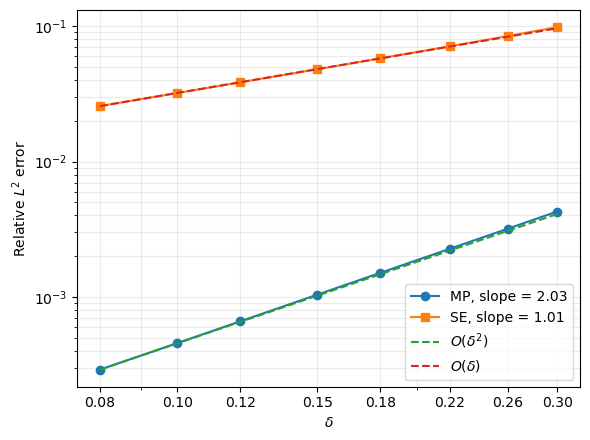

In [18]:
# ============================================================
# Main 1: fixed N, varying delta
# ============================================================

# parameters
seed = 1234
N = 1000

deltas = np.array([0.08, 0.10, 0.12, 0.15, 0.18, 0.22, 0.26, 0.30])

eta = 1e-9
ell = 3.0

q_box = 0.60
p_box = 0.40
E_max = 0.14

p_slice = np.array([0.15, -0.10])
q_min, q_max = -0.30, 0.30
n_grid = 61


# data
rng = np.random.default_rng(seed)
z0 = sample_initial_conditions(N, rng, q_box, p_box, E_max)
data = generate_flow_data(z0, deltas)

_, _, Z_test = make_test_slice(q_min, q_max, n_grid, p_slice)
H_true = H(Z_test)


# learning
err_mp, err_se = [], []

for delta in deltas:
    z1 = data[delta]

    x_mp, v_mp = observations(z0, z1, delta, "MP")
    x_se, v_se = observations(z0, z1, delta, "SE")

    c_mp = fit_estimator(x_mp, v_mp, eta, ell)
    c_se = fit_estimator(x_se, v_se, eta, ell)

    H_mp = predict_H(Z_test, x_mp, c_mp, ell)
    H_se = predict_H(Z_test, x_se, c_se, ell)

    e_mp = relative_hamiltonian_error(H_mp, H_true)
    e_se = relative_hamiltonian_error(H_se, H_true)

    err_mp.append(e_mp)
    err_se.append(e_se)

    print(f"delta={delta:.3f} | MP={e_mp:.4e} | SE={e_se:.4e}")

err_mp = np.asarray(err_mp)
err_se = np.asarray(err_se)

slope_mp = fitted_slope(deltas, err_mp)
slope_se = fitted_slope(deltas, err_se)

print(f"\nMP slope = {slope_mp:.3f}")
print(f"SE slope = {slope_se:.3f}")

def plot_delta_convergence(deltas, err_mp, err_se, slope_mp, slope_se):
    plt.figure(figsize=(6, 4.5))
    plt.loglog(deltas, err_mp, "o-", label=rf"MP, slope = {slope_mp:.2f}")
    plt.loglog(deltas, err_se, "s-", label=rf"SE, slope = {slope_se:.2f}")
    plt.loglog(deltas, err_mp[0] * (deltas / deltas[0])**2, "--", label=r"$O(\delta^2)$")
    plt.loglog(deltas, err_se[0] * (deltas / deltas[0]), "--", label=r"$O(\delta)$")
    plt.xlabel(r"$\delta$")
    plt.ylabel(r"Relative $L^2$ error")
    plt.xticks(deltas, [f"{d:.2f}" for d in deltas])
    plt.gca().xaxis.set_minor_formatter(NullFormatter())
    plt.legend()
    plt.grid(True, which="both", alpha=0.25)
    plt.tight_layout()
    os.makedirs("fig", exist_ok=True)
    plt.savefig("fig/HH_error_vs_delta.pdf", bbox_inches="tight")
    plt.savefig("fig/HH_error_vs_delta.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_delta_convergence(deltas, err_mp, err_se, slope_mp, slope_se)

N=  25 | eta=2.515e-09 | MP=2.1034e-02 | SE=6.0715e-02
N=  50 | eta=2.115e-09 | MP=9.1573e-03 | SE=6.4352e-02
N= 100 | eta=1.778e-09 | MP=3.8017e-03 | SE=6.4348e-02
N= 200 | eta=1.495e-09 | MP=2.1536e-03 | SE=6.4215e-02
N= 400 | eta=1.257e-09 | MP=1.8572e-03 | SE=6.4414e-02
N= 700 | eta=1.093e-09 | MP=1.8685e-03 | SE=6.4328e-02
N=1000 | eta=1.000e-09 | MP=1.8720e-03 | SE=6.4278e-02


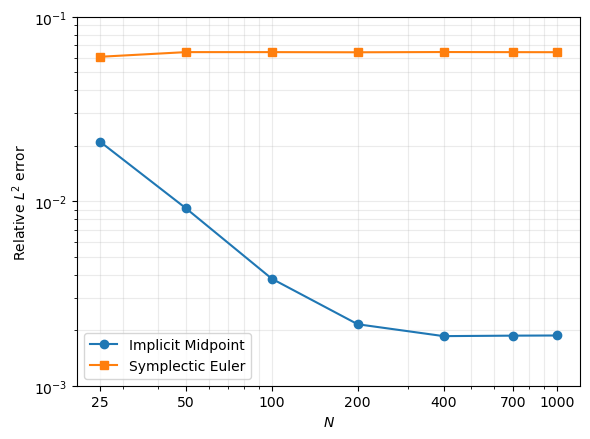

In [19]:
# ============================================================
# Main 2: fixed delta, varying N
# ============================================================

# parameters
seed = 1234
delta = 0.20

N_values = np.array([25, 50, 100, 200, 400, 700, 1000])
N_max = N_values.max()

ell = 3.0

# eta_N ~ N^{-1/[2(gamma+1)]}
gamma = 1.0
eta_ref = 1e-9
N_ref = 1000

def eta_schedule(N):
    return eta_ref * (N_ref / N)**(1.0 / (2.0 * (gamma + 1.0)))

q_box = 0.60
p_box = 0.40
E_max = 0.14

p_slice = np.array([0.15, -0.10])
q_min, q_max = -0.30, 0.30
n_grid = 61


# data
rng = np.random.default_rng(seed)
z0_all = sample_initial_conditions(N_max, rng, q_box, p_box, E_max)
z1_all = np.array([exact_flow(z, delta) for z in z0_all])

_, _, Z_test = make_test_slice(q_min, q_max, n_grid, p_slice)
H_true = H(Z_test)


# learning
err_mp, err_se = [], []
eta_values = []

for N in N_values:
    eta = eta_schedule(N)
    eta_values.append(eta)

    z0, z1 = z0_all[:N], z1_all[:N]

    x_mp, v_mp = observations(z0, z1, delta, "MP")
    x_se, v_se = observations(z0, z1, delta, "SE")

    c_mp = fit_estimator(x_mp, v_mp, eta, ell)
    c_se = fit_estimator(x_se, v_se, eta, ell)

    H_mp = predict_H(Z_test, x_mp, c_mp, ell)
    H_se = predict_H(Z_test, x_se, c_se, ell)

    e_mp = relative_hamiltonian_error(H_mp, H_true)
    e_se = relative_hamiltonian_error(H_se, H_true)

    err_mp.append(e_mp)
    err_se.append(e_se)

    print(
        f"N={N:4d} | eta={eta:.3e} | "
        f"MP={e_mp:.4e} | SE={e_se:.4e}"
    )

err_mp = np.asarray(err_mp)
err_se = np.asarray(err_se)
eta_values = np.asarray(eta_values)


# plot
def plot_sample_convergence(N_values, err_mp, err_se):
    plt.figure(figsize=(6,4.5))
    plt.loglog(N_values,err_mp,"o-",label="Implicit Midpoint")
    plt.loglog(N_values,err_se,"s-",label="Symplectic Euler")

    plt.xlabel(r"$N$")
    plt.ylabel(r"Relative $L^2$ error")
    plt.xticks(N_values,[str(N) for N in N_values])
    plt.ylim(1e-3,1e-1)

    plt.gca().xaxis.set_minor_formatter(NullFormatter())
    plt.legend()
    plt.grid(True,which="both",alpha=0.25)
    plt.tight_layout()

    os.makedirs("figs",exist_ok=True)
    plt.savefig("figs/HH_error_vs_N.png",dpi=300,bbox_inches="tight")
    plt.show()


plot_sample_convergence(N_values, err_mp, err_se)

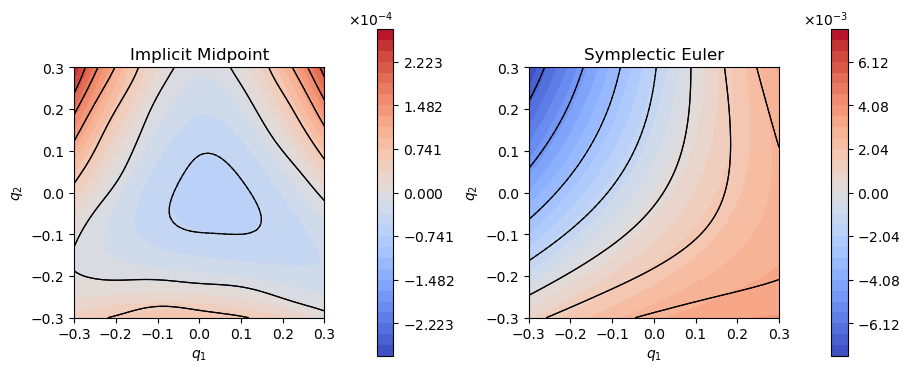

MP target error = 6.925e-02, correlation = 0.9976
SE target error = 8.538e-02, correlation = 0.9964


In [20]:
# ============================================================
# Main 3: leading inverse-modified corrections
# ============================================================

def hessV(q):
    q1, q2 = q[..., 0], q[..., 1]
    A = np.zeros(q.shape[:-1] + (2, 2))
    A[..., 0, 0] = 1.0 + 2.0 * q2
    A[..., 0, 1] = 2.0 * q1
    A[..., 1, 0] = 2.0 * q1
    A[..., 1, 1] = 1.0 - 2.0 * q2
    return A


def C_MP(z):
    q, p = z[..., :2], z[..., 2:]
    g, HV = gradV(q), hessV(q)
    return (np.einsum("...i,...ij,...j->...", p, HV, p) + np.sum(g**2, axis=-1)) / 24.0


def C_SE(z):
    q, p = z[..., :2], z[..., 2:]
    return 0.5 * np.sum(p * gradV(q), axis=-1)

# parameters
seed = 1234
delta = 0.15
N = 1000

eta = 1e-9
ell = 3.0

q_box = 0.60
p_box = 0.40
E_max = 0.14

p_slice = np.array([0.15, -0.10])
q_min, q_max = -0.30, 0.30
n_grid = 61


# data
rng = np.random.default_rng(seed)
z0 = sample_initial_conditions(N, rng, q_box, p_box, E_max)
z1 = np.array([exact_flow(z, delta) for z in z0])

Q1, Q2, Z_test = make_test_slice(q_min, q_max, n_grid, p_slice)
H_true = H(Z_test)


# learning
x_mp, v_mp = observations(z0, z1, delta, "MP")
x_se, v_se = observations(z0, z1, delta, "SE")

c_mp = fit_estimator(x_mp, v_mp, eta, ell)
c_se = fit_estimator(x_se, v_se, eta, ell)

H_mp = predict_H(Z_test, x_mp, c_mp, ell)
H_se = predict_H(Z_test, x_se, c_se, ell)


# learned biases, modulo constants
B_mp = H_mp - H_true
B_se = H_se - H_true

B_mp -= np.mean(B_mp)
B_se -= np.mean(B_se)


# leading inverse-modified biases, modulo constants
T_mp = delta**2 * C_MP(Z_test)
T_se = delta * C_SE(Z_test)

T_mp -= np.mean(T_mp)
T_se -= np.mean(T_se)


# reshape for plotting
B_mp_plot = B_mp.reshape(Q1.shape)
B_se_plot = B_se.reshape(Q1.shape)

T_mp_plot = T_mp.reshape(Q1.shape)
T_se_plot = T_se.reshape(Q1.shape)


# common color scales within each row
lim_mp = max(np.max(np.abs(T_mp_plot)), np.max(np.abs(B_mp_plot)))
lim_se = max(np.max(np.abs(T_se_plot)), np.max(np.abs(B_se_plot)))

levels_mp = np.linspace(-lim_mp, lim_mp, 31)
levels_se = np.linspace(-lim_se, lim_se, 31)


# plot
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)

# MP: theory as filled contour, learned bias as contour lines
im_mp = ax[0].contourf(Q1, Q2, T_mp_plot, levels=levels_mp, cmap="coolwarm")
ax[0].contour(Q1, Q2, B_mp_plot, levels=levels_mp[::3],
              colors="k", linewidths=0.8)

ax[0].set_title(r"Implicit Midpoint")
ax[0].set_xlabel(r"$q_1$")
ax[0].set_ylabel(r"$q_2$")
ax[0].set_aspect("equal")


# SE: theory as filled contour, learned bias as contour lines
im_se = ax[1].contourf(Q1, Q2, T_se_plot, levels=levels_se, cmap="coolwarm")
ax[1].contour(Q1, Q2, B_se_plot, levels=levels_se[::3],
              colors="k", linewidths=0.8)

ax[1].set_title(r"Symplectic Euler")
ax[1].set_xlabel(r"$q_1$")
ax[1].set_ylabel(r"$q_2$")
ax[1].set_aspect("equal")

ax[0].contour(
    Q1, Q2, B_mp_plot,
    levels=levels_mp[::3],
    colors="k",
    linewidths=0.9,
    linestyles="solid"
)

ax[1].contour(
    Q1, Q2, B_se_plot,
    levels=levels_se[::3],
    colors="k",
    linewidths=0.9,
    linestyles="solid"
)

# scientific-notation colorbars
formatter_mp = ScalarFormatter(useMathText=True)
formatter_mp.set_powerlimits((0, 0))

formatter_se = ScalarFormatter(useMathText=True)
formatter_se.set_powerlimits((0, 0))

cb_mp = fig.colorbar(im_mp, ax=ax[0], shrink=0.88, format=formatter_mp)
cb_se = fig.colorbar(im_se, ax=ax[1], shrink=0.88, format=formatter_se)

cb_mp.update_ticks()
cb_se.update_ticks()


# save
os.makedirs("fig", exist_ok=True)
plt.savefig("fig/HH_inverse_target.pdf", bbox_inches="tight")
plt.savefig("fig/HH_inverse_target.png", dpi=300, bbox_inches="tight")

plt.show()


# diagnostics
err_target_mp = np.linalg.norm(B_mp - T_mp) / np.linalg.norm(T_mp)
err_target_se = np.linalg.norm(B_se - T_se) / np.linalg.norm(T_se)

corr_mp = np.corrcoef(B_mp, T_mp)[0, 1]
corr_se = np.corrcoef(B_se, T_se)[0, 1]

print(f"MP target error = {err_target_mp:.3e}, correlation = {corr_mp:.4f}")
print(f"SE target error = {err_target_se:.3e}, correlation = {corr_se:.4f}")

delta=0.030 | MP: Q1=7.922e-05, Q2=7.759e-05, Q3=7.761e-05 | SE: Q1=9.682e-03, Q2=3.566e-04, Q3=9.068e-05
delta=0.040 | MP: Q1=9.436e-05, Q2=7.752e-05, Q3=7.754e-05 | SE: Q1=1.289e-02, Q2=6.105e-04, Q3=1.191e-04
delta=0.050 | MP: Q1=1.242e-04, Q2=7.747e-05, Q3=7.746e-05 | SE: Q1=1.609e-02, Q2=9.409e-04, Q3=1.785e-04
delta=0.060 | MP: Q1=1.681e-04, Q2=7.745e-05, Q3=7.740e-05 | SE: Q1=1.928e-02, Q2=1.349e-03, Q3=2.783e-04
delta=0.080 | MP: Q1=2.914e-04, Q2=7.757e-05, Q3=7.729e-05 | SE: Q1=2.566e-02, Q2=2.411e-03, Q3=6.387e-04
delta=0.100 | MP: Q1=4.569e-04, Q2=7.804e-05, Q3=7.719e-05 | SE: Q1=3.204e-02, Q2=3.830e-03, Q3=1.312e-03
delta=0.120 | MP: Q1=6.620e-04, Q2=7.918e-05, Q3=7.707e-05 | SE: Q1=3.843e-02, Q2=5.661e-03, Q3=2.472e-03
delta=0.150 | MP: Q1=1.043e-03, Q2=8.352e-05, Q3=7.681e-05 | SE: Q1=4.805e-02, Q2=9.338e-03, Q3=5.722e-03
delta=0.180 | MP: Q1=1.511e-03, Q2=9.465e-05, Q3=7.631e-05 | SE: Q1=5.775e-02, Q2=1.443e-02, Q3=1.216e-02
delta=0.220 | MP: Q1=2.272e-03, Q2=1.314e-04, 

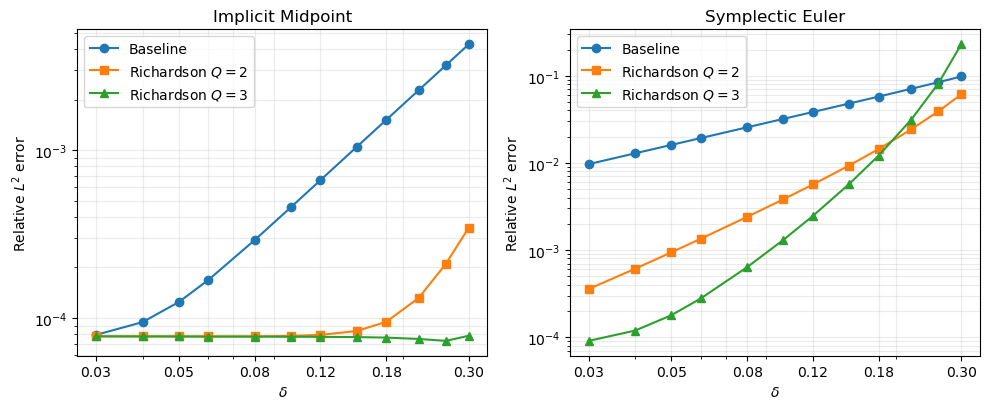

In [21]:
# ============================================================
# Main 4: Richardson: fixed N, varying delta
# ============================================================

# parameters
seed = 1234
N = 1000
deltas = np.array([0.03, 0.04, 0.05, 0.06, 0.08, 0.10, 0.12, 0.15, 0.18, 0.22, 0.26, 0.30])

eta = 1e-9
ell = 3.0

q_box = 0.60
p_box = 0.40
E_max = 0.14

p_slice = np.array([0.15, -0.10])
q_min, q_max = -0.30, 0.30
n_grid = 61

# data
rng = np.random.default_rng(seed)
z0 = sample_initial_conditions(N, rng, q_box, p_box, E_max)
Q1, Q2, Z_test = make_test_slice(q_min, q_max, n_grid, p_slice)
H_true = H(Z_test)

# errors
err_mp_q1, err_mp_q2, err_mp_q3 = [], [], []
err_se_q1, err_se_q2, err_se_q3 = [], [], []

for delta in deltas:
    z1 = np.array([exact_flow(z, delta) for z in z0])
    z2 = np.array([exact_flow(z, 2.0 * delta) for z in z0])
    z3 = np.array([exact_flow(z, 3.0 * delta) for z in z0])

    x_mp_1, v_mp_1 = observations(z0, z1, delta, "MP")
    x_mp_2, v_mp_2 = observations(z0, z2, 2.0 * delta, "MP")
    x_mp_3, v_mp_3 = observations(z0, z3, 3.0 * delta, "MP")

    x_se_1, v_se_1 = observations(z0, z1, delta, "SE")
    x_se_2, v_se_2 = observations(z0, z2, 2.0 * delta, "SE")
    x_se_3, v_se_3 = observations(z0, z3, 3.0 * delta, "SE")

    c_mp_1 = fit_estimator(x_mp_1, v_mp_1, eta, ell)
    c_mp_2 = fit_estimator(x_mp_2, v_mp_2, eta, ell)
    c_mp_3 = fit_estimator(x_mp_3, v_mp_3, eta, ell)

    c_se_1 = fit_estimator(x_se_1, v_se_1, eta, ell)
    c_se_2 = fit_estimator(x_se_2, v_se_2, eta, ell)
    c_se_3 = fit_estimator(x_se_3, v_se_3, eta, ell)

    H_mp_1 = predict_H(Z_test, x_mp_1, c_mp_1, ell)
    H_mp_2 = predict_H(Z_test, x_mp_2, c_mp_2, ell)
    H_mp_3 = predict_H(Z_test, x_mp_3, c_mp_3, ell)

    H_se_1 = predict_H(Z_test, x_se_1, c_se_1, ell)
    H_se_2 = predict_H(Z_test, x_se_2, c_se_2, ell)
    H_se_3 = predict_H(Z_test, x_se_3, c_se_3, ell)

    H_mp_r2 = richardson_Q2(H_mp_1, H_mp_2, "MP")
    H_mp_r3 = richardson_Q3(H_mp_1, H_mp_2, H_mp_3, "MP")

    H_se_r2 = richardson_Q2(H_se_1, H_se_2, "SE")
    H_se_r3 = richardson_Q3(H_se_1, H_se_2, H_se_3, "SE")

    e_mp_q1 = relative_hamiltonian_error(H_mp_1, H_true)
    e_mp_q2 = relative_hamiltonian_error(H_mp_r2, H_true)
    e_mp_q3 = relative_hamiltonian_error(H_mp_r3, H_true)

    e_se_q1 = relative_hamiltonian_error(H_se_1, H_true)
    e_se_q2 = relative_hamiltonian_error(H_se_r2, H_true)
    e_se_q3 = relative_hamiltonian_error(H_se_r3, H_true)

    err_mp_q1.append(e_mp_q1)
    err_mp_q2.append(e_mp_q2)
    err_mp_q3.append(e_mp_q3)

    err_se_q1.append(e_se_q1)
    err_se_q2.append(e_se_q2)
    err_se_q3.append(e_se_q3)

    print(f"delta={delta:.3f} | "
          f"MP: Q1={e_mp_q1:.3e}, Q2={e_mp_q2:.3e}, Q3={e_mp_q3:.3e} | "
          f"SE: Q1={e_se_q1:.3e}, Q2={e_se_q2:.3e}, Q3={e_se_q3:.3e}")

err_mp_q1 = np.asarray(err_mp_q1)
err_mp_q2 = np.asarray(err_mp_q2)
err_mp_q3 = np.asarray(err_mp_q3)

err_se_q1 = np.asarray(err_se_q1)
err_se_q2 = np.asarray(err_se_q2)
err_se_q3 = np.asarray(err_se_q3)

s_mp_q1 = fitted_slope(deltas, err_mp_q1)
s_mp_q2 = fitted_slope(deltas, err_mp_q2)
s_mp_q3 = fitted_slope(deltas, err_mp_q3)

s_se_q1 = fitted_slope(deltas, err_se_q1)
s_se_q2 = fitted_slope(deltas, err_se_q2)
s_se_q3 = fitted_slope(deltas, err_se_q3)

print()
print(f"MP: Q1={s_mp_q1:.3f}, Q2={s_mp_q2:.3f}, Q3={s_mp_q3:.3f}")
print(f"SE: Q1={s_se_q1:.3f}, Q2={s_se_q2:.3f}, Q3={s_se_q3:.3f}")


def plot_richardson(deltas, err_mp_q1, err_mp_q2, err_mp_q3,err_se_q1, err_se_q2, err_se_q3):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
    ax[0].loglog(deltas, err_mp_q1, "o-", label="Baseline")
    ax[0].loglog(deltas, err_mp_q2, "s-", label=r"Richardson $Q=2$")
    ax[0].loglog(deltas, err_mp_q3, "^-", label=r"Richardson $Q=3$")
    ax[0].set_title("Implicit Midpoint")
    ax[1].loglog(deltas, err_se_q1, "o-", label="Baseline")
    ax[1].loglog(deltas, err_se_q2, "s-", label=r"Richardson $Q=2$")
    ax[1].loglog(deltas, err_se_q3, "^-", label=r"Richardson $Q=3$")
    ax[1].set_title("Symplectic Euler")

    xticks = [0.03, 0.05, 0.08, 0.12, 0.18, 0.30]

    for a in ax:
        a.set_xlabel(r"$\delta$")
        a.set_ylabel(r"Relative $L^2$ error")
        a.set_xticks(xticks)
        a.set_xticklabels([f"{d:.2f}" for d in xticks])
        a.xaxis.set_minor_formatter(NullFormatter())
        a.grid(True, which="both", alpha=0.25)
        a.legend()

    plt.tight_layout()
    os.makedirs("fig", exist_ok=True)
    plt.savefig("fig/HH_Richardson_vs_delta.pdf", bbox_inches="tight")
    plt.savefig("fig/HH_Richardson_vs_delta.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_richardson(deltas, err_mp_q1, err_mp_q2, err_mp_q3, err_se_q1, err_se_q2, err_se_q3)

noise= 0.00% | MP: 4.569e-04, 7.804e-05, 7.719e-05 | SE: 3.204e-02, 3.830e-03, 1.312e-03
noise= 0.10% | MP: 3.951e-03, 5.250e-03, 5.971e-03 | SE: 3.203e-02, 8.889e-03, 1.273e-02
noise= 0.20% | MP: 7.863e-03, 1.051e-02, 1.195e-02 | SE: 3.243e-02, 1.640e-02, 2.545e-02
noise= 0.50% | MP: 1.965e-02, 2.631e-02, 2.992e-02 | SE: 3.603e-02, 3.995e-02, 6.369e-02
noise= 1.00% | MP: 3.938e-02, 5.273e-02, 5.994e-02 | SE: 4.812e-02, 7.970e-02, 1.275e-01
noise= 2.00% | MP: 7.898e-02, 1.057e-01, 1.202e-01 | SE: 8.194e-02, 1.597e-01, 2.550e-01
noise= 5.00% | MP: 1.969e-01, 2.637e-01, 2.996e-01 | SE: 1.966e-01, 3.989e-01, 6.344e-01
noise=10.00% | MP: 3.899e-01, 5.215e-01, 5.919e-01 | SE: 3.749e-01, 7.744e-01, 1.253e+00


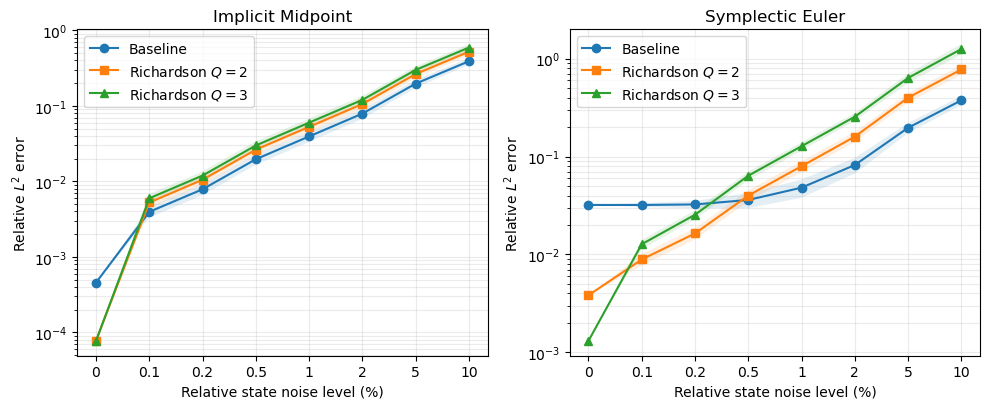

In [22]:
# ============================================================
# Main 5: Noisy trajectory states and Richardson correction
# ============================================================

# parameters
seed = 1234
N = 1000
delta = 0.10
eta = 1e-9
ell = 3.0
noise_levels = np.array([0.0, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.10])
n_repeats = 10

q_box = 0.60
p_box = 0.40
E_max = 0.14
p_slice = np.array([0.15,-0.10])
q_min,q_max = -0.30,0.30
n_grid = 61

# data
rng = np.random.default_rng(seed)
z0 = sample_initial_conditions(N,rng,q_box,p_box,E_max)
z1 = np.array([exact_flow(z,delta) for z in z0])
z2 = np.array([exact_flow(z,2*delta) for z in z0])
z3 = np.array([exact_flow(z,3*delta) for z in z0])

_,_,Z_test = make_test_slice(q_min,q_max,n_grid,p_slice)
H_true = H(Z_test)

# relative state-noise scale
z_all = np.vstack([z0,z1,z2,z3])
z_rms = np.linalg.norm(z_all)/np.sqrt(z_all.size)

# noisy fits from perturbed endpoint states
def noisy_predictions(z0,zs,step,method,noise_levels,n_repeats,eta,ell,Z_test,seed,z_rms):
    rng = np.random.default_rng(seed)
    pred = np.zeros((n_repeats,len(noise_levels),len(Z_test)))

    for r in range(n_repeats):
        e0 = rng.standard_normal(z0.shape)
        es = rng.standard_normal(zs.shape)

        for k,rho in enumerate(noise_levels):
            z0_noisy = z0 + rho*z_rms*e0
            zs_noisy = zs + rho*z_rms*es
            X,v = observations(z0_noisy,zs_noisy,step,method)

            M,d = X.shape
            G = gram_matrix(X,ell)
            cf = cho_factor(G+M*eta*np.eye(M*d),lower=True,check_finite=False)
            c = cho_solve(cf,v.reshape(-1),check_finite=False).reshape(M,d)

            gradK = matern52_grad1(X,Z_test,ell)
            feature = np.einsum("ab,ikb->ika",J,gradK)
            pred[r,k] = np.einsum("ika,ia->k",feature,c)

    return pred

# same state-noise realizations for MP/SE at each stride
H_mp_1 = noisy_predictions(z0,z1,delta,"MP",noise_levels,n_repeats,eta,ell,Z_test,seed+1,z_rms)
H_se_1 = noisy_predictions(z0,z1,delta,"SE",noise_levels,n_repeats,eta,ell,Z_test,seed+1,z_rms)

H_mp_2 = noisy_predictions(z0,z2,2*delta,"MP",noise_levels,n_repeats,eta,ell,Z_test,seed+2,z_rms)
H_se_2 = noisy_predictions(z0,z2,2*delta,"SE",noise_levels,n_repeats,eta,ell,Z_test,seed+2,z_rms)

H_mp_3 = noisy_predictions(z0,z3,3*delta,"MP",noise_levels,n_repeats,eta,ell,Z_test,seed+3,z_rms)
H_se_3 = noisy_predictions(z0,z3,3*delta,"SE",noise_levels,n_repeats,eta,ell,Z_test,seed+3,z_rms)

# Richardson combinations
H_mp_q1 = H_mp_1
H_mp_q2 = (4/3)*H_mp_1-(1/3)*H_mp_2
H_mp_q3 = 1.5*H_mp_1-0.6*H_mp_2+0.1*H_mp_3

H_se_q1 = H_se_1
H_se_q2 = 2*H_se_1-H_se_2
H_se_q3 = 3*H_se_1-3*H_se_2+H_se_3

# errors
def repeated_errors(H_pred,H_true):
    R,K,_ = H_pred.shape
    err = np.zeros((R,K))
    for r in range(R):
        for k in range(K):
            err[r,k] = relative_hamiltonian_error(H_pred[r,k],H_true)
    return err

err_mp_q1 = repeated_errors(H_mp_q1,H_true)
err_mp_q2 = repeated_errors(H_mp_q2,H_true)
err_mp_q3 = repeated_errors(H_mp_q3,H_true)
err_se_q1 = repeated_errors(H_se_q1,H_true)
err_se_q2 = repeated_errors(H_se_q2,H_true)
err_se_q3 = repeated_errors(H_se_q3,H_true)

# summary
def mean_std(err):
    return np.mean(err,axis=0),np.std(err,axis=0)

mp1,mp1_std = mean_std(err_mp_q1)
mp2,mp2_std = mean_std(err_mp_q2)
mp3,mp3_std = mean_std(err_mp_q3)
se1,se1_std = mean_std(err_se_q1)
se2,se2_std = mean_std(err_se_q2)
se3,se3_std = mean_std(err_se_q3)

for k,rho in enumerate(noise_levels):
    print(f"noise={100*rho:5.2f}% | MP: {mp1[k]:.3e}, {mp2[k]:.3e}, {mp3[k]:.3e} | "
          f"SE: {se1[k]:.3e}, {se2[k]:.3e}, {se3[k]:.3e}")

# plot
def plot_noise_effect(noise_levels,mp1,mp1_std,mp2,mp2_std,mp3,mp3_std,
                      se1,se1_std,se2,se2_std,se3,se3_std):
    x = np.arange(len(noise_levels))
    xlabels = [f"{100*rho:g}" for rho in noise_levels]
    fig,ax = plt.subplots(1,2,figsize=(10,4.2))

    ax[0].semilogy(x,mp1,"o-",label="Baseline")
    ax[0].semilogy(x,mp2,"s-",label=r"Richardson $Q=2$")
    ax[0].semilogy(x,mp3,"^-",label=r"Richardson $Q=3$")
    ax[0].fill_between(x,np.maximum(mp1-mp1_std,1e-16),mp1+mp1_std,alpha=0.12)
    ax[0].fill_between(x,np.maximum(mp2-mp2_std,1e-16),mp2+mp2_std,alpha=0.12)
    ax[0].fill_between(x,np.maximum(mp3-mp3_std,1e-16),mp3+mp3_std,alpha=0.12)
    ax[0].set_title("Implicit Midpoint")

    ax[1].semilogy(x,se1,"o-",label="Baseline")
    ax[1].semilogy(x,se2,"s-",label=r"Richardson $Q=2$")
    ax[1].semilogy(x,se3,"^-",label=r"Richardson $Q=3$")
    ax[1].fill_between(x,np.maximum(se1-se1_std,1e-16),se1+se1_std,alpha=0.12)
    ax[1].fill_between(x,np.maximum(se2-se2_std,1e-16),se2+se2_std,alpha=0.12)
    ax[1].fill_between(x,np.maximum(se3-se3_std,1e-16),se3+se3_std,alpha=0.12)
    ax[1].set_title("Symplectic Euler")

    for a in ax:
        a.set_xticks(x)
        a.set_xticklabels(xlabels)
        a.set_xlabel("Relative state noise level (%)")
        a.set_ylabel(r"Relative $L^2$ error")
        a.grid(True,which="both",alpha=0.25)
        a.legend()

    plt.tight_layout()
    os.makedirs("fig",exist_ok=True)
    plt.savefig("fig/HH_state_noise_Richardson.pdf",bbox_inches="tight")
    plt.savefig("fig/HH_state_noise_Richardson.png",dpi=300,bbox_inches="tight")
    plt.show()

plot_noise_effect(noise_levels,mp1,mp1_std,mp2,mp2_std,mp3,mp3_std, se1,se1_std,se2,se2_std,se3,se3_std)


delta=0.01
N=400, L= 1, T=0.01 | MP=2.5639e-04 | SE=3.3364e-03
N=200, L= 2, T=0.02 | MP=6.2942e-04 | SE=3.2591e-03
N=100, L= 4, T=0.04 | MP=1.8183e-03 | SE=3.8479e-03
N= 50, L= 8, T=0.08 | MP=3.7891e-03 | SE=5.2609e-03
N= 25, L=16, T=0.16 | MP=8.0274e-03 | SE=8.7968e-03

delta=0.05
N=400, L= 1, T=0.05 | MP=2.6796e-04 | SE=1.6188e-02
N=200, L= 2, T=0.10 | MP=4.6296e-04 | SE=1.6116e-02
N=100, L= 4, T=0.20 | MP=1.4786e-03 | SE=1.6534e-02
N= 50, L= 8, T=0.40 | MP=2.8604e-03 | SE=1.7780e-02
N= 25, L=16, T=0.80 | MP=6.0164e-03 | SE=1.6379e-02

delta=0.10
N=400, L= 1, T=0.10 | MP=4.9724e-04 | SE=3.2154e-02
N=200, L= 2, T=0.20 | MP=6.0715e-04 | SE=3.2083e-02
N=100, L= 4, T=0.40 | MP=1.3151e-03 | SE=3.2620e-02
N= 50, L= 8, T=0.80 | MP=1.7885e-03 | SE=3.3099e-02
N= 25, L=16, T=1.60 | MP=3.6216e-03 | SE=3.2361e-02


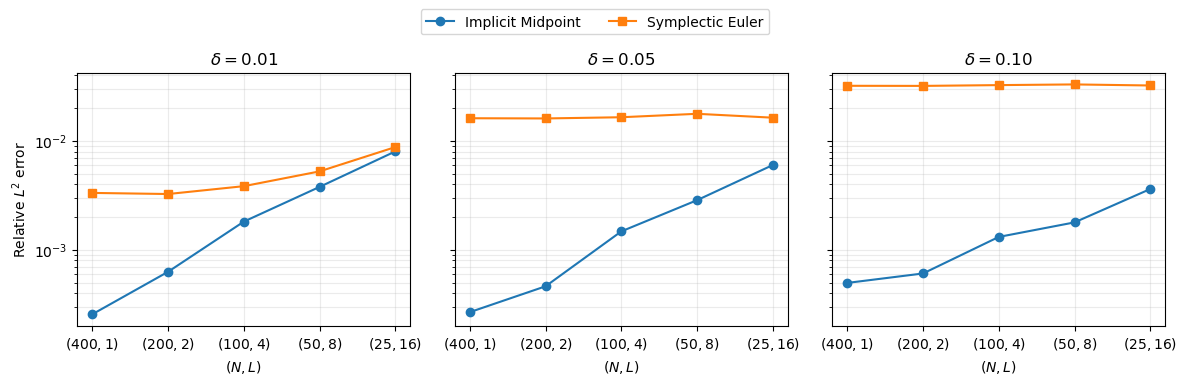

In [23]:
# ============================================================
# Main 6: Fixed observation budget: N x L = 400, varying delta
# ============================================================

# parameters
seed = 1234
M_total = 400
NL_pairs = [(400,1), (200,2), (100,4), (50,8), (25,16)]
delta_values = [0.01, 0.05, 0.10]

eta = 1e-9
ell = 3.0

q_box = 0.60
p_box = 0.40
E_max = 0.14

p_slice = np.array([0.15,-0.10])
q_min, q_max = -0.30, 0.30
n_grid = 61

def exact_trajectory(z0, delta, L):
    times = np.arange(L+1)*delta
    sol = solve_ivp(lambda t,z:XH(z), (0.0,L*delta), z0, method="DOP853",
                    rtol=1e-12, atol=1e-14, t_eval=times)
    if not sol.success: raise RuntimeError(sol.message)
    return sol.y.T

def trajectory_observations(traj, delta, method):
    z0 = traj[:,:-1,:].reshape(-1,4)
    z1 = traj[:,1:,:].reshape(-1,4)
    return observations(z0,z1,delta,method)

# test set
_, _, Z_test = make_test_slice(q_min,q_max,n_grid,p_slice)
H_true = H(Z_test)

# learning
results = {}

for delta in delta_values:
    err_mp, err_se = [], []
    print(f"\ndelta={delta:.2f}")

    for j,(N,L) in enumerate(NL_pairs):
        rng = np.random.default_rng(seed+j)
        z0 = sample_initial_conditions(N,rng,q_box,p_box,E_max)
        traj = np.array([exact_trajectory(z,delta,L) for z in z0])

        x_mp,v_mp = trajectory_observations(traj,delta,"MP")
        x_se,v_se = trajectory_observations(traj,delta,"SE")

        c_mp = fit_estimator(x_mp,v_mp,eta,ell)
        c_se = fit_estimator(x_se,v_se,eta,ell)

        H_mp = predict_H(Z_test,x_mp,c_mp,ell)
        H_se = predict_H(Z_test,x_se,c_se,ell)

        e_mp = relative_hamiltonian_error(H_mp,H_true)
        e_se = relative_hamiltonian_error(H_se,H_true)

        err_mp.append(e_mp)
        err_se.append(e_se)

        print(f"N={N:3d}, L={L:2d}, T={L*delta:.2f} | MP={e_mp:.4e} | SE={e_se:.4e}")

    results[delta] = (np.asarray(err_mp),np.asarray(err_se))

# plot
def plot_fixed_budget_multi_delta(delta_values,results,NL_pairs):
    x = np.arange(len(NL_pairs))
    labels = [rf"$({N},{L})$" for N,L in NL_pairs]

    fig,ax = plt.subplots(1,3,figsize=(12,3.8),sharey=True)

    for a,delta in zip(ax,delta_values):
        err_mp,err_se = results[delta]
        a.semilogy(x,err_mp,"o-",label="Implicit Midpoint")
        a.semilogy(x,err_se,"s-",label="Symplectic Euler")
        a.set_xticks(x)
        a.set_xticklabels(labels)
        a.set_xlabel(r"$(N,L)$")
        a.set_title(rf"$\delta={delta:.2f}$")
        a.grid(True,which="both",alpha=0.25)

    ax[0].set_ylabel(r"Relative $L^2$ error")

    handles,labels_legend = ax[0].get_legend_handles_labels()
    fig.legend(handles,labels_legend,loc="upper center",ncol=2,bbox_to_anchor=(0.5,1.02))
    plt.tight_layout(rect=[0,0,1,0.93])
    os.makedirs("fig",exist_ok=True)
    plt.savefig("fig/HH_fixed_budget_multi_delta.pdf",bbox_inches="tight")
    plt.savefig("fig/HH_fixed_budget_multi_delta.png",dpi=300,bbox_inches="tight")
    plt.show()

plot_fixed_budget_multi_delta(delta_values,results,NL_pairs)